In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import shutil

In [15]:
# Script to standardize images in a dataset by padding and resizing

# Define the paths
original_dataset_path = '../datasets'
transformed_dataset_path = '../datasets/standardized'

# Create the new directory structure
os.makedirs(transformed_dataset_path, exist_ok=True)
categories = ['marchandise', 'administration', 'passager_gros', 'passager_petit', 'plaisance', 'restaurant']
for category in categories:
    os.makedirs(os.path.join(transformed_dataset_path, category), exist_ok=True)

# Iterate through each category and image in the original dataset
for category in categories:
    original_category_path = os.path.join(original_dataset_path, category)
    transformed_category_path = os.path.join(transformed_dataset_path, category)

    for filename in os.listdir(original_category_path):
        if filename.endswith(('.jpg', '.jpeg', '.png')):
            # Load the original image
            original_image_path = os.path.join(original_category_path, filename)
            original_image = Image.open(original_image_path)

            # Calculate the padding
            width, height = original_image.size
            if width > height:
                padding = (width - height) // 2
                pad_transform = transforms.Pad((0, padding, 0, padding), fill=0)  # Pad the top and bottom
            else:
                padding = (height - width) // 2
                pad_transform = transforms.Pad((padding, 0, padding, 0), fill=0)  # Pad the left and right

            # Define the transformation pipeline
            transform = transforms.Compose([
                pad_transform,  # Pad the image to make it square
                transforms.Resize(256)  # Resize the padded image to 256x256 pixels
            ])

            # Apply the transformation pipeline to the image
            transformed_image = transform(original_image)

            # Save the transformed image
            transformed_image_path = os.path.join(transformed_category_path, filename)
            transformed_image.save(transformed_image_path)

In [19]:
# Data augmentation pipeline

# Define the data augmentation pipeline
data_augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # Randomly flip the image horizontally
    transforms.RandomVerticalFlip(),  # Randomly flip the image vertically
    transforms.RandomRotation(30),  # Randomly rotate the image by up to 30 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Randomly adjust the brightness, contrast, saturation, and hue of the image
    transforms.ToTensor()  # Convert the image to a tensor
])

In [20]:
standardized_dataset_path = '../datasets/standardized'
standardized_augmented_dataset_path = '../datasets/standardized_augmented'

# Create the augmented dataset directory
os.makedirs(standardized_augmented_dataset_path, exist_ok=True)

# Define the number of augmented images to generate for each original image
num_augmented_images = 5

# Iterate through each category and image in the standardized dataset
for category in os.listdir(standardized_dataset_path):
    category_path = os.path.join(standardized_dataset_path, category)
    if os.path.isdir(category_path):
        augmented_category_path = os.path.join(standardized_augmented_dataset_path, category)
        os.makedirs(augmented_category_path, exist_ok=True)

        for filename in os.listdir(category_path):
            if filename.endswith(('.jpg', '.jpeg', '.png')):
                # Load the original image
                original_image_path = os.path.join(category_path, filename)
                original_image = Image.open(original_image_path)

                # Copy the original image to the standardized_augmented directory
                shutil.copy(original_image_path, os.path.join(augmented_category_path, filename))

                # Generate multiple augmented versions of the image
                for i in range(num_augmented_images):
                    # Apply the data augmentation pipeline to the image
                    augmented_image = data_augmentation(original_image)

                    # Convert the augmented image to a PIL image and save it
                    augmented_image_pil = transforms.ToPILImage()(augmented_image)
                    augmented_image_path = os.path.join(augmented_category_path, f'augmented_{i}_{filename}')
                    augmented_image_pil.save(augmented_image_path)

In [21]:
# Define the paths to the training and testing datasets
train_dataset_path = '../datasets/train'
test_dataset_path = '../datasets/test'

# Split the dataset into training and testing sets
os.makedirs(train_dataset_path, exist_ok=True)
os.makedirs(test_dataset_path, exist_ok=True)

for category in os.listdir(standardized_augmented_dataset_path):
    category_path = os.path.join(standardized_augmented_dataset_path, category)
    if os.path.isdir(category_path):
        train_category_path = os.path.join(train_dataset_path, category)
        test_category_path = os.path.join(test_dataset_path, category)
        os.makedirs(train_category_path, exist_ok=True)
        os.makedirs(test_category_path, exist_ok=True)

        for filename in os.listdir(category_path):
            if filename.endswith(('.jpg', '.jpeg', '.png')):
                image_path = os.path.join(category_path, filename)
                if np.random.random() < 0.8:  # 80% of the images will be used for training
                    shutil.copy(image_path, os.path.join(train_category_path, filename))
                else:  # 20% of the images will be used for testing
                    shutil.copy(image_path, os.path.join(test_category_path, filename))

In [27]:
# Verify and correct the image formats in the training and testing datasets

# Define the target dimensions for the images
target_size = (256, 256)

# Define the resize transformation
resize_transform = transforms.Resize(target_size)

# Function to resize images in a dataset
def resize_images(dataset_path):
    # Iterate through each category and image in the dataset
    for category in os.listdir(dataset_path):
        category_path = os.path.join(dataset_path, category)
        if os.path.isdir(category_path):
            for filename in os.listdir(category_path):
                if filename.endswith(('.jpg', '.jpeg', '.png')):
                    # Load the image
                    image_path = os.path.join(category_path, filename)
                    image = Image.open(image_path)

                    # Resize the image
                    resized_image = resize_transform(image)

                    # Save the resized image
                    resized_image.save(image_path)

# Resize images in the train and test datasets
resize_images(train_dataset_path)
resize_images(test_dataset_path)

In [28]:
# Load the training and testing datasets
train_dataset = ImageFolder(train_dataset_path, transform=transforms.ToTensor())
test_dataset = ImageFolder(test_dataset_path, transform=transforms.ToTensor())

# Create the data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [33]:
# Calculate class weights to handle class imbalance
from collections import Counter

# Initialize a counter to count the occurrences of each class
class_counts = Counter()

# Iterate through the train_loader to count the occurrences of each class
for _, labels in train_loader:
    class_counts.update(labels.tolist())

# Calculate the class weights
num_classes = len(class_counts)
class_weights = {class_idx: 1.0 / class_counts[class_idx] for class_idx in class_counts}

# Convert the class weights to a tensor
class_weights_tensor = torch.tensor([class_weights[class_idx] for class_idx in range(num_classes)], dtype=torch.float32)

In [34]:
from torchvision.models import ResNet18_Weights

# Import the pre-trained ResNet18 model 
weights = ResNet18_Weights.IMAGENET1K_V1
model = models.resnet18(weights=weights)

# Freeze all layers except the final fully connected layer
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the final fully connected layer
for param in model.fc.parameters():
    param.requires_grad = True

# Get the number of input features for the final fully connected layer
num_features = model.fc.in_features

# Define the number of output classes
num_classes = len(categories)
print(f'Number of classes: {num_classes}')

# Replace the final fully connected layer with a new layer with the appropriate number of output features
model.fc = nn.Linear(num_features, num_classes)

Number of classes: 6


In [35]:
import copy

num_epochs = 10

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# Define the device to use for training
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Initialize variables to track the best model
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

# Initialize variables to track the training progress
train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []

# Fine-tune the model
for epoch in range(num_epochs):
    print(f'Epoch {epoch}/{num_epochs - 1}')
    print('-' * 10)

    # Each epoch has a training and validation phase
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()  # Set model to training mode
        else:
            model.eval()   # Set model to evaluate mode

        running_loss = 0.0
        running_corrects = 0

        # Iterate over data
        for inputs, labels in train_loader if phase == 'train' else test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                # Backward pass and optimization only in training phase
                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            # Statistics
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / (len(train_loader.dataset) if phase == 'train' else len(test_loader.dataset))
        epoch_acc = running_corrects.double() / (len(train_loader.dataset) if phase == 'train' else len(test_loader.dataset))

        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        # Track the training progress
        if phase == 'train':
            train_loss_history.append(epoch_loss)
            train_acc_history.append(epoch_acc)
        else:
            val_loss_history.append(epoch_loss)
            val_acc_history.append(epoch_acc)



Epoch 0/9
----------
train Loss: 1.6533 Acc: 0.3749
val Loss: 1.4228 Acc: 0.4992
Epoch 1/9
----------
train Loss: 1.2747 Acc: 0.6012
val Loss: 1.1089 Acc: 0.6539
Epoch 2/9
----------
train Loss: 1.0740 Acc: 0.6649
val Loss: 1.2030 Acc: 0.5507
Epoch 3/9
----------
train Loss: 0.9349 Acc: 0.6942
val Loss: 0.9045 Acc: 0.7138
Epoch 4/9
----------
train Loss: 0.8471 Acc: 0.7361
val Loss: 0.8454 Acc: 0.7504
Epoch 5/9
----------
train Loss: 0.7785 Acc: 0.7449
val Loss: 0.7466 Acc: 0.7920
Epoch 6/9
----------
train Loss: 0.7124 Acc: 0.7675
val Loss: 0.8090 Acc: 0.7471
Epoch 7/9
----------
train Loss: 0.6897 Acc: 0.7545
val Loss: 0.7649 Acc: 0.7604
Epoch 8/9
----------
train Loss: 0.6436 Acc: 0.7708
val Loss: 0.6505 Acc: 0.8170
Epoch 9/9
----------
train Loss: 0.6157 Acc: 0.7813
val Loss: 0.6427 Acc: 0.8003


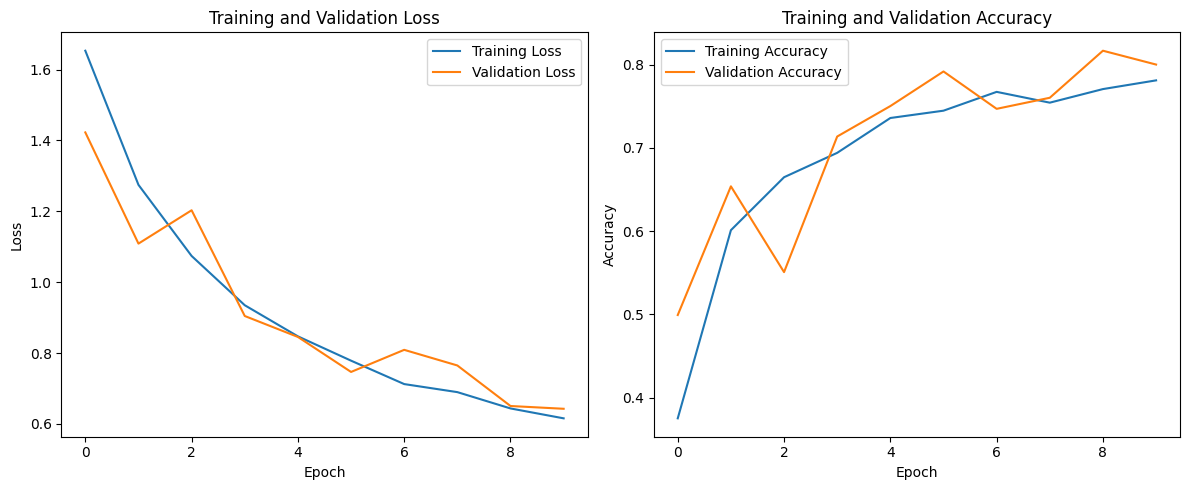

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Training Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_history, label='Training Accuracy')
plt.plot(val_acc_history, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

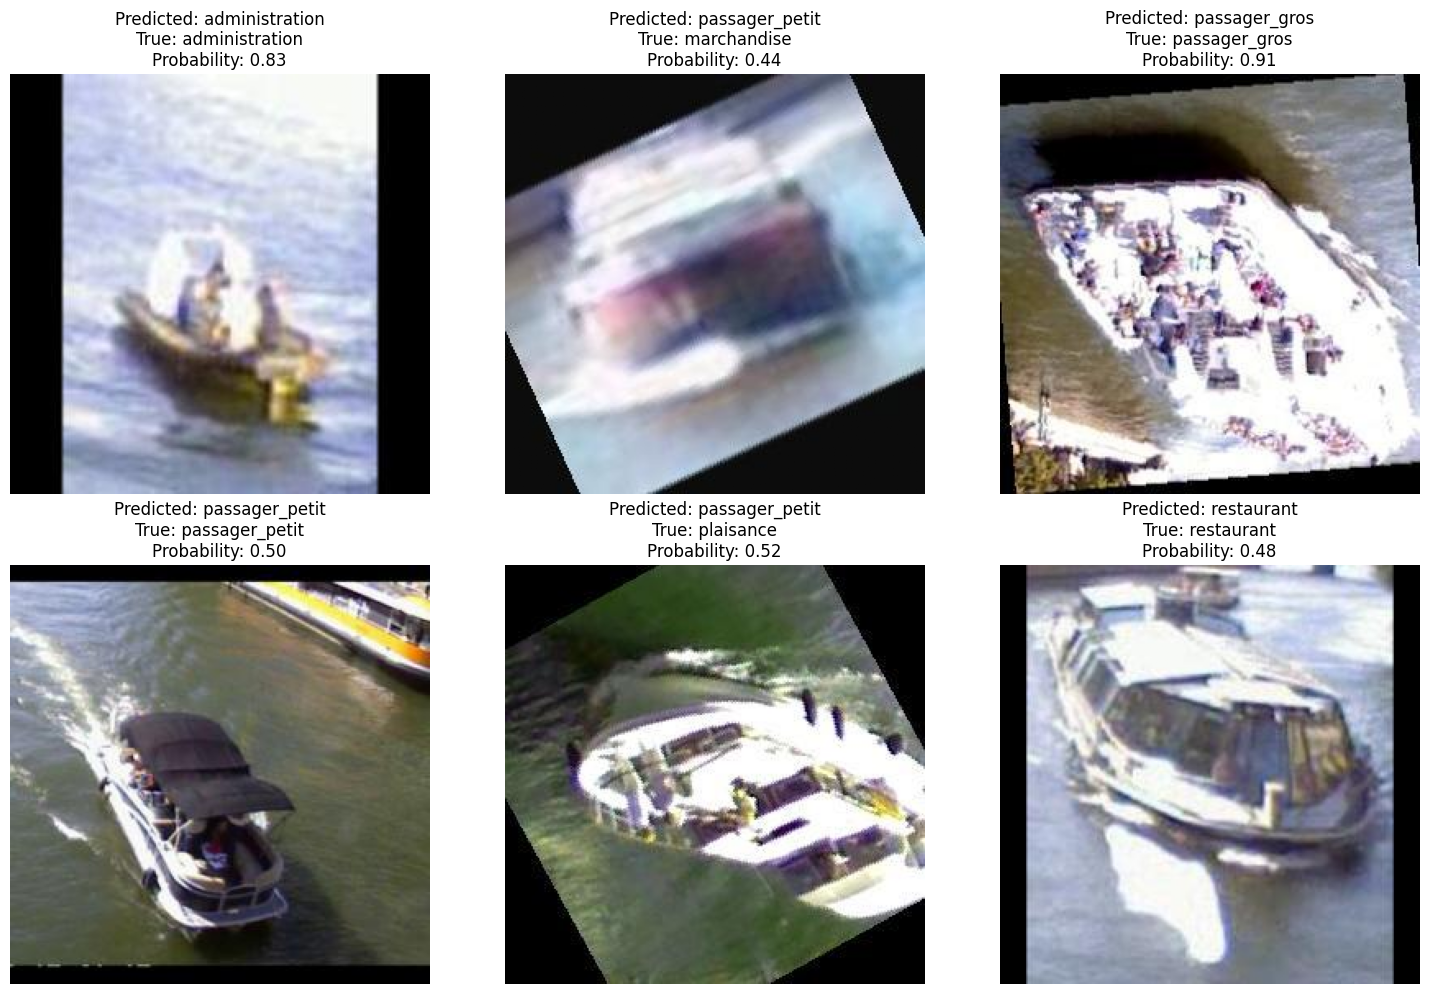

In [ ]:
from collections import defaultdict

# Load the pre-trained model weights
model_weights = torch.load('boat_recognition_model.pth')

# Initialize a ResNet18 model without pre-trained weights
model = models.resnet18(weights=None)
num_classes = 6
# Modify the final fully connected layer to match the number of classes
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)

# Load the model weights into the model
model.load_state_dict(model_weights, strict=False)
model.eval()

# Define image transformations
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

# Create a dataset and data loader for testing
test_dataset = ImageFolder(test_dataset_path, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Get class names and create a dictionary mapping class indices to names
class_names = test_dataset.classes
class_names_dict = {i: name for i, name in enumerate(class_names)}

# Store images by their class labels
images_by_class = defaultdict(list)

# Iterate through the test dataset and store images in the dictionary
for images, labels in test_loader:
    for img, label in zip(images, labels):
        class_idx = label.item()
        images_by_class[class_idx].append(img)

# Ensure all classes are represented in the dictionary
assert len(images_by_class) == num_classes

# Create a figure to display sample images with predictions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

# Display one random image per class with prediction information
for i, class_idx in enumerate(images_by_class.keys()):
    random_idx = np.random.randint(0, len(images_by_class[class_idx]))
    img = images_by_class[class_idx][random_idx]

    # Make a prediction for the image
    with torch.no_grad():
        output = model(img.unsqueeze(0))
        probabilities = torch.nn.functional.softmax(output, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1)
        predicted_probability = probabilities[0][predicted_class].item()

    # Get the predicted and true class names
    predicted_class_name = class_names_dict[predicted_class.item()]
    true_class_name = class_names_dict[class_idx]

    # Display the image with prediction information
    axes[i].imshow(img.permute(1, 2, 0))
    axes[i].set_title(f'Predicted: {predicted_class_name}\nTrue: {true_class_name}\nProbability: {predicted_probability:.2f}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()